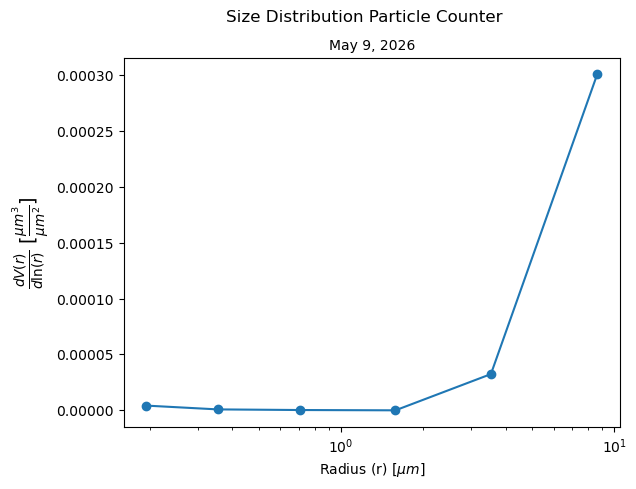

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

particle = pd.read_csv('ParticleCounter05.09.csv')
alt = pd.read_csv('AltitudeData05.09.csv')

particle['Time_raw'] = pd.to_datetime(particle['Time'], errors='coerce')

wrong_start = pd.Timestamp('2026-02-08 13:58:00')  # this is local time
correct_start = pd.Timestamp('2026-05-09 15:58:00')  # I replaced it with UTC Time
time_shift = correct_start - wrong_start

particle['Time'] = particle['Time_raw'] + time_shift  # correction on time

# I use lasttime instead of time since the format for time is inconsistent.
alt['Time'] = pd.to_datetime(alt['lasttime'], format="%m/%d/%y %H:%M", errors='coerce')

start_time = pd.Timestamp('2026-05-09 16:18:00')

particle_strip = particle[(particle['Time']>=start_time) & (particle['Time']<=alt['Time'].max())]

data = pd.merge(particle_strip,alt, on=['Time'], how='left')
df = data[['Time','Size1','Count1 (dM3)','Size2','Count2 (dM3)',
          'Size3','Count3 (dM3)','Size4','Count4 (dM3)','Size5',
          'Count5 (dM3)','Size6','Count6 (dM3)','altitude']].copy()

df['altitude'] = pd.to_numeric(df['altitude'], errors='coerce')
df['altitude'] = df['altitude'].interpolate(method='linear',limit_area='inside')

count_cols = ['Count1 (dM3)','Count2 (dM3)','Count3 (dM3)',
                  'Count4 (dM3)','Count5 (dM3)','Count6 (dM3)']

D_edges = np.array([df['Size1'][0],df['Size2'][0],df['Size3'][0],
                    df['Size4'][0],df['Size5'][0],df['Size6'][0],30],dtype=float)
r_edges = D_edges/2

r_mid = np.sqrt(r_edges[:-1]*r_edges[1:])
dlnr = np.log(r_edges[1:]/r_edges[:-1])

dN_dM3 = df[count_cols].to_numpy(dtype=float)
dVdlnr_local = (4*np.pi/3)*(r_mid**3)*(dN_dM3/dlnr)

for i,r in enumerate(r_mid):
    df[f'dVdlnr{i+1}'] = dVdlnr_local[:,i]

# Only Considering the Ascending Data
idx_max_alt = df['altitude'].idxmax()
df_ascent = df.loc[:idx_max_alt].copy()

z = np.array(df_ascent['altitude'])
dz = np.abs(np.diff(z)) # calculate Δz
dVdlnr1 = np.array(df_ascent['dVdlnr1'])
dVdlnr2 = np.array(df_ascent['dVdlnr2'])
dVdlnr3 = np.array(df_ascent['dVdlnr3'])
dVdlnr4 = np.array(df_ascent['dVdlnr4'])
dVdlnr5 = np.array(df_ascent['dVdlnr5'])
dVdlnr6 = np.array(df_ascent['dVdlnr6'])

# Left Riemann Sum and Convert to um^2
p1 = sum(dVdlnr1[:-1]*dz)*(1e-6)**2
p2 = sum(dVdlnr2[:-1]*dz)*(1e-6)**2
p3 = sum(dVdlnr3[:-1]*dz)*(1e-6)**2
p4 = sum(dVdlnr4[:-1]*dz)*(1e-6)**2
p5 = sum(dVdlnr5[:-1]*dz)*(1e-6)**2
p6 = sum(dVdlnr6[:-1]*dz)*(1e-6)**2

py = np.array([p1,p2,p3,p4,p5,p6],dtype=float)

plt.plot(r_mid,py,'o-')
plt.xscale('log')
plt.ylabel(r'$\frac{dV(r)}{d\ln(r)}$ [$\frac{\mu m^3}{\mu m^2}$]', fontsize=14)
plt.xlabel(r'Radius (r) [$\mu m$]')
plt.suptitle("Size Distribution Particle Counter")
plt.title("May 9, 2026", fontsize=10)
plt.show()